# Imports

In [10]:
# # use a python 3.11 environment, and install dynamiqs >= 0.3.0

# uncomment and run the line below once to install the required dependencies. You can also install these packages in your terminal using pip.
# !pip install "dynamiqs>=0.3.0" cmaes scipy

In [24]:
import dynamiqs as dq
import jax.numpy as jnp
from matplotlib import pyplot as plt

from jax import vmap, jit
from cmaes import SepCMA

from scipy.optimize import curve_fit
from scipy.optimize import least_squares
import numpy as np

# dq.set_progress_meter(False)

In [38]:
# model: y = A * exp(-t/tau) + C
def model(p, t):
    A, tau, C = p
    return A * jnp.exp(-t/tau) + C

def residuals(p, x, y):
    return model(p, x) - y


def robust_exp_fit(x, y):
    # smart initialization
    A0 = y.max() - y.min()
    C0 = y.min()
    tau0 = (x.max() - x.min())
    p0 = [A0, tau0, C0]

    # robust fit (soft_l1 or huber are key)
    res = least_squares(
        residuals,
        p0,
        args=(x, y),
        bounds=([0, 0, -jnp.inf], [jnp.inf, jnp.inf, jnp.inf]),
        loss="soft_l1",   # try "huber" too
        f_scale=0.1       # tune based on noise level
    )

    A, tau, C = res.x
    y_fit = model(res.x.copy(), x)

    return {
        "popt": res.x,
        "y_fit": y_fit,
    }

In [ ]:

def get_lifetime_with_variables(initial_state, tfinal, g_2, eps_d):
    na = 15 # Hilbert space dimension
    nb = 5
    a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilation operator memory
    b = dq.tensor(dq.eye(na), dq.destroy(nb)) # annihilation operator buffer

    kappa_b = 10 # MHz
    kappa_a = 1 # MHz

    # alpha estimation
    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
    alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

    #print(f"Estimated cat size: {alpha_estimate:.2f}")

    # hamiltonian including: exchanging cat and buffer 
    H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

    # loss/ dissipation
    loss_b = jnp.sqrt(kappa_b) * b
    loss_a = jnp.sqrt(kappa_a) * a

    # define evaluation time frame
    tsave = jnp.linspace(0, tfinal, 100)

    # for init state
    g_state = dq.coherent(na, alpha_estimate)
    e_state = dq.coherent(na, -alpha_estimate)

    basis = {
        "+z": g_state,
        "-z": e_state,
        "+x": (g_state + e_state) / jnp.sqrt(2),
        "-x": (g_state - e_state) / jnp.sqrt(2),
        "+y": (g_state + 1j*e_state) / jnp.sqrt(2),
        "-y": (g_state - 1j*e_state) / jnp.sqrt(2),
    }


    # sigmax in cat space
    sx = basis["+x"] @ basis["+x"].dag() - basis["-x"] @ basis["-x"].dag()
    sx = dq.tensor(sx, dq.eye(nb))
    
    # This construction of sigmaz will not work without a good estimate of alpha, which is hard to come by in experiment.
    # TODO
    sz = basis["+z"] @ basis["+z"].dag() - basis["-z"] @ basis["-z"].dag()
    sz = dq.tensor(sz, dq.eye(nb))

    # initial state
    psi0 = dq.tensor(basis[initial_state], dq.fock(nb,0))

    # get density matrix for each time step
    res = dq.mesolve(
        H, 
        [loss_b, loss_a], 
        psi0, 
        tsave, 
        options=dq.Options(progress_meter=False, save_states=False),
        exp_ops=[sx, sz]
    )

    return res


def get_TX_TZ(g_2, eps_d):
    
    res_z = get_lifetime_with_variables("+z", 200, g_2, eps_d)
    szt = res_z.expects[1,:].real
    ts_z = res_z.tsave
    fit_z = robust_exp_fit(ts_z, szt)
    Tz = fit_z["popt"][1]

    res_x = get_lifetime_with_variables("+x",1.0, g_2, eps_d)
    sxt = res_x.expects[0,:].real
    ts_x = res_x.tsave
    fit_x = robust_exp_fit(ts_x, sxt)
    Tx = fit_x["popt"][1]

    return Tx, Tz

def reward_function(p):
    # p = [g_2.real, g_2.imag, eps_d.real, eps_d.imag, lamb]
    g_2 = p[0] + 1j*p[1]
    eps_d = p[2] + 1j*p[3]
    lamb = p[4]

    eta = 500 # somewhat arbitrary
    Tx, Tz = get_TX_TZ(g_2, eps_d)

    #g = (jnp.log10(eta*Tx/Tz))**2
    g = eta*Tx - Tz
    f = Tx + Tz
    L = -f + lamb*g

    return L

batched_reward_function = jit(vmap(reward_function))
jit_reward_function = jit(reward_function)

g_2_array = jnp.linspace(0.1,5,5)
eps_d_array = jnp.linspace(0.1,10,5)



# all parameter combinations
G, E = jnp.meshgrid(g_2_array, eps_d_array, indexing="ij")

# flatten
G = G.ravel()
E = E.ravel()

# build vectors:
# [g_2, 0, eps_d, 0, 1]
params = jnp.stack(
    [
        G,
        jnp.zeros_like(G),
        E,
        jnp.zeros_like(G),
        jnp.ones_like(G),
    ],
    axis=1
)

losses = batched_reward_function(params)

fig, ax = plt.subplots(1,1, figsize=(3,2), dpi=200)

im = ax.pcolormesh(g_2_array, eps_d_array,losses, cmap="coolwarm")
cbar = fig.colorbar(im, ax=ax)




c:\Users\zoernchen2\miniconda3\envs\myenv\Lib\site-packages\equinox\_module\_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[3]
This BatchTracer with object id 1962820320160 was created on line:
  C:\Users\zoernchen2\AppData\Local\Temp\ipykernel_26232\1847186082.py:15:9 (robust_exp_fit)
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [27]:
reward_function([0.1, 0, 0.1, 0, 1])

np.float64(21.584095264521874)

In [ ]:
BATCH_SIZE = 12
N_EPOCHS = 200
N_KNOBS = 2

# initial values
mean0 = jnp.array([0.5, 2])     # start near optimum
sigma0 = 0.2                    # exploration scale


# SYNTHETIC DRIFT
# ----------------------------------------
amp_factor_delta_drift_func = lambda ep: 0.8 * jnp.sin(2 * jnp.pi * 0.01 * ep) #+ 0.6 * jnp.cos(2* jnp.pi * 0.02 *ep)
# ----------------------------------------


# ----------------------------------------
# CMA-ES setup
# ----------------------------------------

optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    bounds=jnp.array([
        [-1.0, 1.0],   # amp_factor bounds
        [-5.0, 5.0],   # freq_delta_MHz bounds
    ]),
    population_size=BATCH_SIZE,
    seed=0,
)

# ----------------------------------------
# Logging
# ----------------------------------------
mean_history = []
std_history = []
reward_history = []
reward_std_history = []
drift_history = []

# ----------------------------------------
# Training loop
# ----------------------------------------
for epoch in range(N_EPOCHS):
    solutions = []

    drift_history.append([amp_factor_delta_drift_func(epoch), 0.0])

    # Sample population
    xs = []
    for _ in range(optimizer.population_size):
        xs.append(jnp.array(optimizer.ask().tolist() + drift_history[-1]))

    xs = jnp.array(xs)
    rewards = batched_pi_pulse_loss_func_under_drift(xs)

    # Format solutions
    solutions = []
    for j in range(len(xs)):
        solutions.append((xs[j][:N_KNOBS], rewards[j]))

    optimizer.tell(solutions)

    # Log
    mean_history.append(jnp.mean(xs[:,:N_KNOBS], axis=0))
    std_history.append(jnp.std(xs[:,:N_KNOBS], axis=0))
    reward_history.append(jnp.mean(rewards))
    reward_std_history.append(jnp.std(rewards))

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | param mean={mean_history[-1]} | param std {std_history[-1]} | avg reward={jnp.mean(rewards):.4f}")



Epoch   0 | param mean=[0.6154126 2.0447474] | param std [0.22261414 0.17998385] | avg reward=-0.7451
Epoch  10 | param mean=[0.6379813 1.5698985] | param std [0.06980838 0.1545896 ] | avg reward=-1.1661
Epoch  20 | param mean=[ 0.3332743 -0.5605424] | param std [0.08400507 0.5663493 ] | avg reward=-1.4294
Epoch  30 | param mean=[ 0.22635941 -0.08822015] | param std [0.02588789 0.13963628] | avg reward=-1.9715
Epoch  40 | param mean=[0.62848556 0.28899872] | param std [0.05489013 0.31443673] | avg reward=-1.8894
Epoch  50 | param mean=[0.6989808  0.06857365] | param std [0.04025247 0.15933946] | avg reward=-1.3974
Epoch  60 | param mean=[-0.17935494 -0.4177732 ] | param std [0.30136105 0.8851222 ] | avg reward=-0.6130
Epoch  70 | param mean=[-0.92538136  0.3807442 ] | param std [0.03409559 0.29088327] | avg reward=-0.3315
Epoch  80 | param mean=[-0.99713564  0.19373974] | param std [0.00126689 0.1608087 ] | avg reward=-0.5340
Epoch  90 | param mean=[-0.95309603  0.08640094] | param std

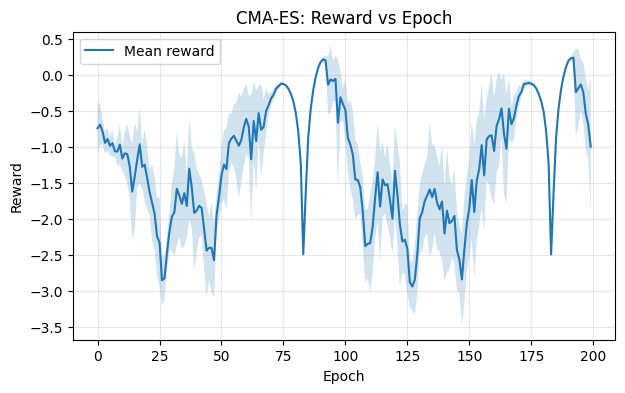

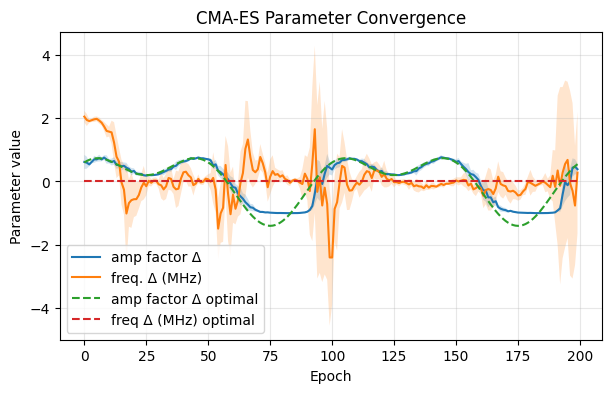

In [ ]:

mean_history = jnp.array(mean_history)
std_history = jnp.array(std_history)
reward_history = jnp.array(reward_history)
reward_std_history = jnp.array(reward_std_history)
drift_history = jnp.array(drift_history)


# ----------------------------------------
# Plot 1: Reward vs epoch
# ----------------------------------------
epochs = jnp.arange(N_EPOCHS)

plt.figure(figsize=(7, 4))
plt.plot(epochs, reward_history, label="Mean reward")
plt.fill_between(
    epochs,
    reward_history - reward_std_history,
    reward_history + reward_std_history,
    alpha=0.2,
)
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.title("CMA-ES: Reward vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ----------------------------------------
# Plot 2: Parameters vs epoch
# ----------------------------------------
plt.figure(figsize=(7, 4))

plt.plot(epochs, mean_history[:, 0], label="amp factor Δ")
plt.fill_between(
    epochs,
    mean_history[:, 0] - std_history[:, 0],
    mean_history[:, 0] + std_history[:, 0],
    alpha=0.2,
)

plt.plot(epochs, mean_history[:, 1], label="freq. Δ (MHz)")
plt.fill_between(
    epochs,
    mean_history[:, 1] - std_history[:, 1],
    mean_history[:, 1] + std_history[:, 1],
    alpha=0.2,
)

# true optimum
plt.plot(drift_history[:, 0], linestyle="--", label="amp factor Δ optimal")
plt.plot(drift_history[:, 1], linestyle="--", label="freq Δ (MHz) optimal")

plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("CMA-ES Parameter Convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
tx, tz = get_TX_TZ(1, 4)
print(tx,tz)

c:\Users\zoernchen2\miniconda3\envs\myenv\Lib\site-packages\equinox\_module\_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


0.17853904566678633 57.18288320662333
